In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
expression = pd.read_csv('../data/count_matrix_HT268B1-Th1H3.tsv', sep = '\t', index_col=0)
counts = pd.read_csv('../data/expression_matrix_HT268B1-Th1H3.tsv', sep = '\t', index_col=0)

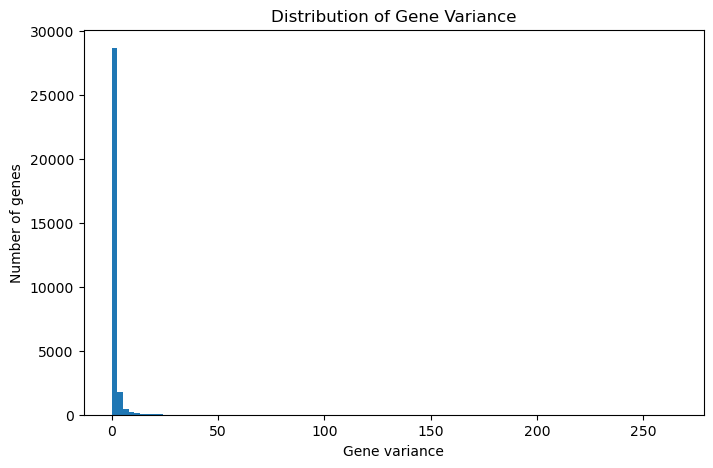

In [4]:
import matplotlib.pyplot as plt

# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(expression)

gene_var = pd.Series(expression.var(axis=0), index=expression.columns)

# 2. Histogram of variance
plt.figure(figsize=(8,5))
plt.hist(gene_var, bins=100)
plt.xlabel("Gene variance")
plt.ylabel("Number of genes")
# plt.yscale('log')
plt.title("Distribution of Gene Variance")
plt.show()

In [5]:
# Pick top 1500 genes
top_n = 1500
top_genes = gene_var.sort_values(ascending=False).head(top_n).index

expression_var = expression[top_genes]
expression_var

,FN1,AP001977.1,COL1A2,CALCRL,CCN2,PCDH17,SLCO2A1,EMCN,NRG1,LINC02755,...,PTPRE,NTHL1,AC099066.1,DBNDD2,AP006545.3,AC009063.3,AP001604.1,EIF5A,CSF2RB,ACSBG1
SKCM_ML499M1-S1_AAACAGCCAATTGACT-1,42.095309,-0.317922,23.948883,-1.512928,10.566045,-1.048126,-0.943248,-1.231709,32.410843,-0.524675,...,-0.424555,-0.228614,-0.042271,-0.174706,-0.164634,-0.273926,-0.107291,5.791791,-0.101858,-0.805109
SKCM_ML499M1-S1_AAACATGCACACAATT-1,4.042214,45.414150,1.747122,-0.290848,-0.219733,-0.157133,-0.188234,-0.257836,3.763560,11.906561,...,-0.448235,-0.065532,-0.049950,-0.051116,-0.045499,-0.086173,-0.018993,-0.117033,-0.144403,-0.077474
SKCM_ML499M1-S1_AAACCAACACCAGGTT-1,45.076558,-0.096732,18.444065,-0.131164,4.521018,-0.042599,-0.058807,-0.121959,17.589887,-0.083864,...,-0.424974,-0.064488,-0.047268,-0.050665,-0.052694,-0.065158,-0.025349,-0.087946,-0.147584,-0.046907
SKCM_ML499M1-S1_AAACCAACAGTTTACG-1,35.795609,9.032747,0.897421,-0.222783,-0.255328,-0.106745,-0.117178,-0.197551,-0.265139,-0.116673,...,-0.464142,-0.082263,-0.051821,-0.064113,-0.065327,-0.085819,-0.032483,-0.120594,-0.159352,-0.100939
SKCM_ML499M1-S1_AAACCAACATGTTGTG-1,14.484955,34.009532,12.132070,-0.204181,10.932675,-0.095660,-0.122383,-0.184561,8.214144,24.441951,...,-0.424585,-0.059677,-0.047275,-0.046839,-0.044401,-0.071824,-0.019345,-0.095949,-0.141129,-0.050623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SKCM_ML499M1-S1_TTTGGTGCAGAGAGCC-1,-2.259657,-0.501469,-1.985777,44.303829,-0.815048,44.646137,4.717248,10.673626,-2.186345,-0.175622,...,-0.728544,-0.145255,-0.081953,-0.109902,-0.069973,-0.258411,-0.022880,-0.372494,-0.188058,-0.419715
SKCM_ML499M1-S1_TTTGTCCCATGTCAGC-1,2.143723,30.128935,12.784839,-0.141748,4.750285,-0.050417,-0.069132,5.447802,18.443766,21.757289,...,-0.422863,-0.062556,-0.047033,-0.049164,-0.050297,-0.065487,-0.023719,-0.087933,-0.145617,-0.044886
SKCM_ML499M1-S1_TTTGTGGCAGGCTGTT-1,22.499303,-0.461660,22.876282,-0.937524,-0.664959,-0.614997,4.360907,-0.799580,44.127896,-0.179932,...,-0.640592,-0.133123,-0.072130,-0.101555,-0.078039,-0.203258,-0.032873,-0.293982,-0.182287,4.241976
SKCM_ML499M1-S1_TTTGTGGCAGTCTAGC-1,4.317916,-0.049598,9.544895,-0.097428,-0.121537,-0.019634,-0.039570,-0.094152,0.009577,-0.066180,...,2.472133,-0.054600,-0.044514,-0.043193,-0.045044,-0.055381,-0.020997,-0.072172,-0.139232,-0.021548


In [6]:
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(expression_var)

pca = PCA(n_components=50)
expression_pca = pca.fit_transform(expression_var)

print("Original shape:", expression_var.shape)
print("Reduced shape:", expression_pca.shape)

Original shape: (1557, 1500)
Reduced shape: (1557, 50)


(array([  3366., 151824., 478650., 655272., 423012., 293178., 204400.,
        130620.,  64618.,  19309.]),
 array([-0.69943103, -0.52948792, -0.35954482, -0.18960172, -0.01965862,
         0.15028449,  0.32022759,  0.49017069,  0.66011379,  0.8300569 ,
         1.        ]),
 <BarContainer object of 10 artists>)

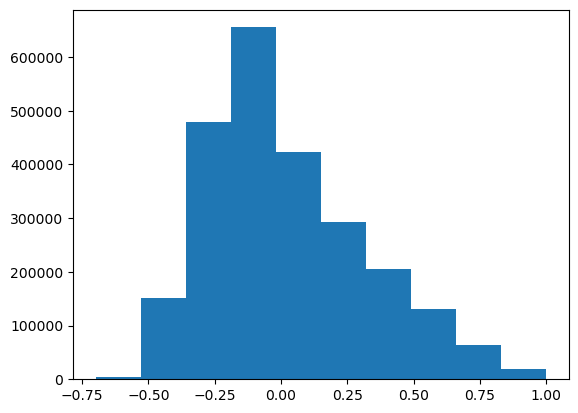

In [7]:

pc_names = [f"PC{i+1}" for i in range(expression_pca.shape[1])]
expression_df_pca = pd.DataFrame(expression_pca, columns=pc_names, index=expression_var.index)
expression_pearson_matrix = expression_df_pca.T.corr(method='pearson')
expression_pearson_flat = expression_pearson_matrix.to_numpy().ravel()
plt.hist(expression_pearson_flat)


In [19]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_matrix = cosine_similarity(expression_df_pca)

# Convert to DataFrame for readability
cosine_matrix = pd.DataFrame(
    cosine_matrix,
    index=expression_df_pca.index,
    columns=expression_df_pca.index
)

print(cosine_matrix)


                    TTTCATCAGCACGATT-1  ACCATTAAGTTAGAGG-1  \
TTTCATCAGCACGATT-1            1.000000            0.252018   
ACCATTAAGTTAGAGG-1            0.252018            1.000000   
CATAGACTCGGCTAGC-1            0.289285            0.775690   
TTCATTCAGTGCACGC-1            0.262601            0.763522   
CTCCAAACAGAAACGT-1            0.149936           -0.156475   
...                                ...                 ...   
GCTGATCCAAAGGTAC-1            0.261502            0.724074   
TTTCCGGGTAGGATCC-1           -0.193206           -0.046691   
AAACCAACATGTTGTG-1            0.313703            0.787192   
TGGTCAGTCACACAGT-1           -0.133092           -0.252124   
TCCTGTTCAATTGAGA-1            0.301033            0.747051   

                    CATAGACTCGGCTAGC-1  TTCATTCAGTGCACGC-1  \
TTTCATCAGCACGATT-1            0.289285            0.262601   
ACCATTAAGTTAGAGG-1            0.775690            0.763522   
CATAGACTCGGCTAGC-1            1.000000            0.917046   
TTCATTC

Number of duplicate columns: 18660


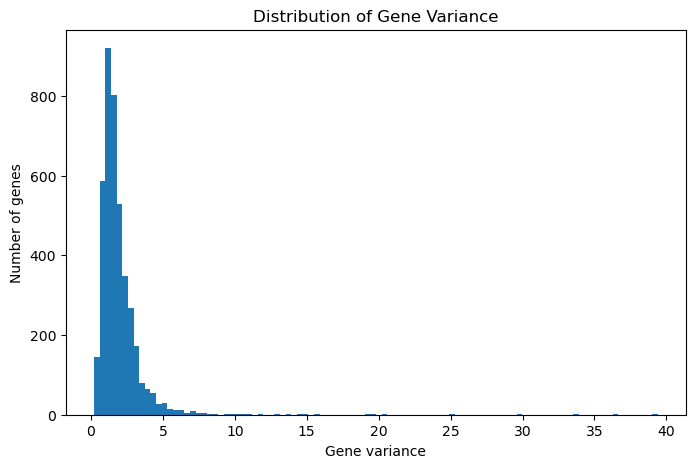

In [13]:
duplicate_mask = counts.T.duplicated()

print("Number of duplicate columns:", duplicate_mask.sum())

# Keep only unique columns (because of the windows causing many to be identical)
counts_unique = counts.loc[:, ~duplicate_mask]


# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(counts_unique)

gene_var = pd.Series(counts_unique.var(axis=0), index=counts_unique.columns)


# 2. Histogram of variance
plt.figure(figsize=(8,5))
plt.hist(gene_var, bins=100)
plt.xlabel("Gene variance")
plt.ylabel("Number of genes")
# plt.yscale('log')
plt.title("Distribution of Gene Variance")
plt.show()



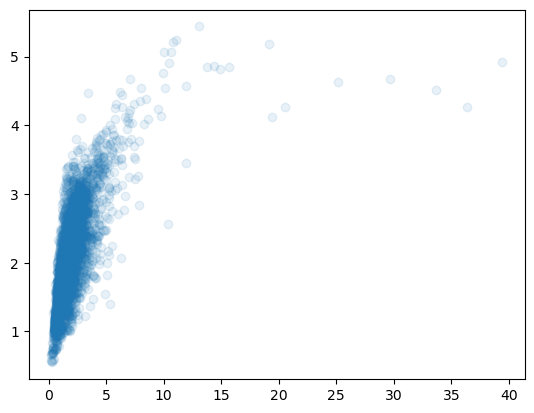

In [21]:
gene_var_plt = pd.Series(counts_unique.var(axis=0), index=counts_unique.columns)


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(counts_unique)
gene_var_plt_scaled = pd.Series(X_scaled.var(axis=0), index=counts_unique.columns)

gene_mean_plt = pd.Series(counts_unique.mean(axis=0), index=counts_unique.columns)
plt.scatter(gene_var_plt, gene_mean_plt, alpha = 0.1)

In [14]:
# Pick top 1500 genes
top_n = 1500
top_genes = gene_var.sort_values(ascending=False).head(top_n).index

counts_var = counts_unique[top_genes]

Original shape: (1440, 1500)
Reduced shape: (1440, 50)


(array([  2092.,  56322., 271296., 523384., 560210., 402888., 200202.,
         52460.,   3260.,   1486.]),
 array([-0.77610956, -0.59849861, -0.42088765, -0.24327669, -0.06566574,
         0.11194522,  0.28955617,  0.46716713,  0.64477809,  0.82238904,
         1.        ]),
 <BarContainer object of 10 artists>)

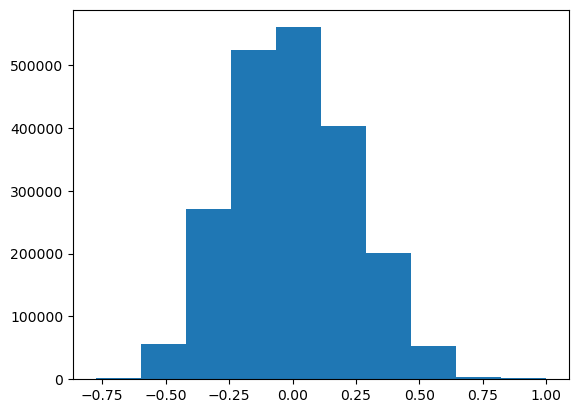

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(counts_var)

pca = PCA(n_components=50)
counts_pca = pca.fit_transform(X_scaled)

print("Original shape:", counts_var.shape)
print("Reduced shape:", counts_pca.shape)


pc_names = [f"PC{i+1}" for i in range(counts_pca.shape[1])]
counts_df_pca = pd.DataFrame(counts_pca, columns=pc_names, index=counts_var.index)
counts_pearson_matrix = counts_df_pca.T.corr(method='pearson')
counts_pearson_flat = counts_pearson_matrix.to_numpy().ravel()
plt.hist(counts_pearson_flat)


In [ ]:
pearson_matrix_exp = expression.T.corr(method='pearson')

print(pearson_matrix_exp)

                    TTTCATCAGCACGATT-1  ACCATTAAGTTAGAGG-1  \
TTTCATCAGCACGATT-1            1.000000            0.577147   
ACCATTAAGTTAGAGG-1            0.577147            1.000000   
CATAGACTCGGCTAGC-1            0.494825            0.494319   
TTCATTCAGTGCACGC-1            0.518058            0.521193   
CTCCAAACAGAAACGT-1            0.760800            0.559726   
...                                ...                 ...   
GCTGATCCAAAGGTAC-1            0.274774            0.284653   
TTTCCGGGTAGGATCC-1            0.569924            0.545769   
AAACCAACATGTTGTG-1            0.517827            0.435184   
TGGTCAGTCACACAGT-1            0.864108            0.584982   
TCCTGTTCAATTGAGA-1            0.472596            0.471986   

                    CATAGACTCGGCTAGC-1  TTCATTCAGTGCACGC-1  \
TTTCATCAGCACGATT-1            0.494825            0.518058   
ACCATTAAGTTAGAGG-1            0.494319            0.521193   
CATAGACTCGGCTAGC-1            1.000000            0.716790   
TTCATTC

Text(0, 0.5, 'Pearson')

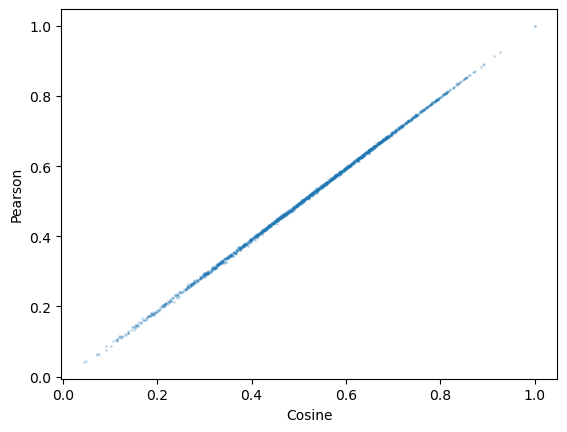

In [ ]:
cosine_exp = cosine_matrix_exp.to_numpy().ravel()
pearson_exp = pearson_matrix_exp.to_numpy().ravel()

cosine_sub = cosine_exp[subset_indices]
pearson_sub = pearson_exp[subset_indices]

import matplotlib.pyplot as plt

plt.scatter(cosine_sub, pearson_sub, alpha = 0.2, s = 1)
plt.xlabel("Cosine")
plt.ylabel("Pearson")

(array([ 11134.,  66982., 153894., 283826., 421478., 487024., 390458.,
        204876.,  50918.,   3010.]),
 array([0.01552789, 0.1139751 , 0.21242231, 0.31086952, 0.40931674,
        0.50776395, 0.60621116, 0.70465837, 0.80310558, 0.90155279,
        1.        ]),
 <BarContainer object of 10 artists>)

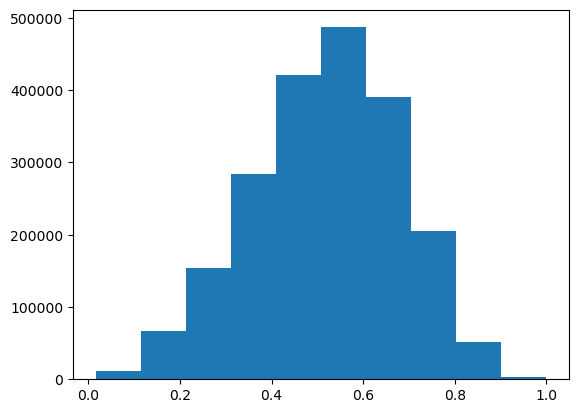

In [ ]:
plt.hist(cosine_exp)